---
# DNN : `Engie`
---

## Packages

In [89]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import LassoCV, ElasticNetCV, Ridge, LinearRegression, RidgeCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import joblib



## Configuration machine

Pour connaître le nombre de coeurs de sa machine :

In [90]:
n_cores = joblib.cpu_count(only_physical_cores=True)
print(f'Nombre de coeurs (physiques): {n_cores}')

Nombre de coeurs (physiques): 1


---
## 1. Données
---

### 1.1. Importation des données

In [91]:
# En local :
# directory = '/Users/vincentlefieux/Dropbox/Docs_ACADEMIQUE/Data/'

# Sur Google colab ou Onyxia (sur un répertoire temporaire) :
# directory = ''

# Sur Google colab (sur le drive) :
from google.colab import drive
drive.mount('/content/drive')
directory = '/content/drive/MyDrive/Datacamp/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
X = pd.read_csv(directory + 'engie_X.csv',
                header    = 0,
                index_col = None,
                sep       = ';',
                decimal   = '.')

y = pd.read_csv(directory + 'engie_Y.csv',
                header    = 0,
                index_col = None,
                sep       = ';',
                decimal   = '.')

In [93]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617386 entries, 0 to 617385
Data columns (total 78 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ID                                   617386 non-null  int64  
 1   MAC_CODE                             617386 non-null  object 
 2   Date_time                            617386 non-null  float64
 3   Pitch_angle                          617386 non-null  float64
 4   Pitch_angle_min                      617386 non-null  float64
 5   Pitch_angle_max                      617386 non-null  float64
 6   Pitch_angle_std                      617386 non-null  float64
 7   Hub_temperature                      617386 non-null  float64
 8   Hub_temperature_min                  617386 non-null  float64
 9   Hub_temperature_max                  617386 non-null  float64
 10  Hub_temperature_std                  617386 non-null  float64
 11  Generator_con

In [94]:
X.head()

,ID,MAC_CODE,Date_time,Pitch_angle,Pitch_angle_min,Pitch_angle_max,Pitch_angle_std,Hub_temperature,Hub_temperature_min,Hub_temperature_max,...,Rotor_speed,Rotor_speed_min,Rotor_speed_max,Rotor_speed_std,Rotor_bearing_temperature,Rotor_bearing_temperature_min,Rotor_bearing_temperature_max,Rotor_bearing_temperature_std,Absolute_wind_direction_c,Nacelle_angle_c
0,1,WT3,1.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,294.19000,294.23999
1,2,WT3,2.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,297.82999,294.23999
2,3,WT3,3.0,92.470001,92.470001,92.470001,0.0,7.00,7.0,7.0,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,322.20999,294.23999
3,4,WT3,4.0,92.470001,92.470001,92.470001,0.0,6.97,6.7,7.0,...,0.0,0.0,0.0,0.0,2.4,2.4,2.4,0.0,318.69000,294.23999
4,5,WT3,5.0,92.470001,92.470001,92.470001,0.0,6.93,6.0,7.0,...,0.0,0.0,0.0,0.0,2.4,2.4,2.5,0.0,314.89001,294.23999


In [95]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617386 entries, 0 to 617385
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      617386 non-null  int64  
 1   TARGET  617386 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 9.4 MB


In [96]:
y.head()

,ID,TARGET
0,1,-0.703
1,2,-0.747
2,3,-0.791
3,4,-0.736
4,5,-1.055


### 1.2. Analyse des données manquantes

On concatène les données pour éviter les erreurs de traitement :

In [97]:
data = pd.merge(X, y, on='ID', how='inner')
print('Dimensions du jeu de données :', data.shape)

Dimensions du jeu de données : (617386, 79)


In [98]:
missing_percentage = data.isna().mean() * 100

print('MISSING VALUES :')
if missing_percentage[missing_percentage != 0].empty:
    print('No')
else:
    print(missing_percentage[missing_percentage != 0].sort_values(ascending=False))

MISSING VALUES :
Grid_voltage                     16.411451
Grid_voltage_min                 16.411451
Grid_voltage_max                 16.411451
Grid_voltage_std                 16.411451
Generator_converter_speed         1.306152
Generator_converter_speed_min     1.306152
Gearbox_inlet_temperature_min     1.306152
Gearbox_inlet_temperature         1.306152
Generator_converter_speed_std     1.306152
Generator_converter_speed_max     1.306152
Gearbox_inlet_temperature_max     1.306152
Gearbox_inlet_temperature_std     1.306152
Absolute_wind_direction_c         0.011662
Nacelle_angle_c                   0.011662
dtype: float64


On constate que les variables `Grid_voltage`, `Grid_voltage_min`, `Grid_voltage_max` et `Grid_voltage_std` présentent beaucoup de données manquantes (environ 16%) ; on analyse ces variables pour décider de leur retrait ou de leur imputation.

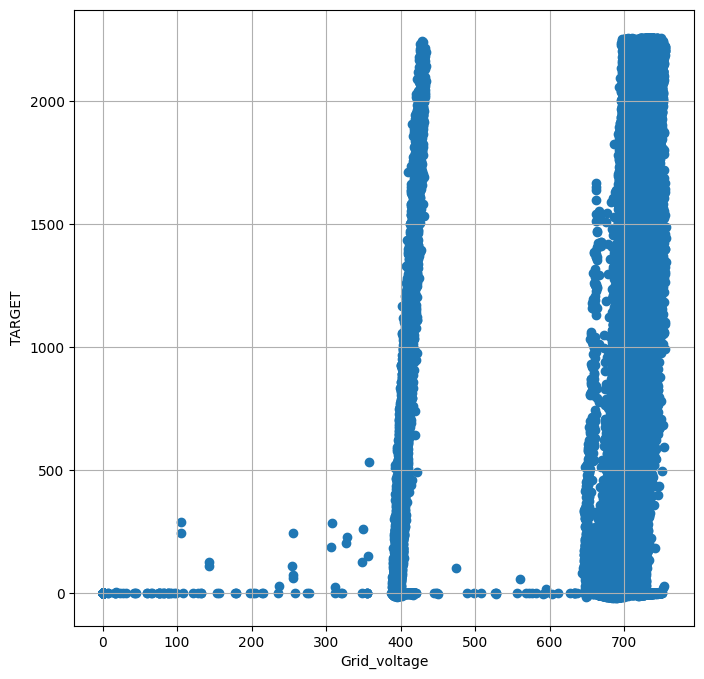

In [99]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(data['Grid_voltage'], data['TARGET'])
ax.grid()
ax.set_xlabel('Grid_voltage')
ax.set_ylabel('TARGET')
plt.show()

Cette analyse nous incite à retirer ces variables dans une première approche car visiblement pas de corrélation de cett variable avec la variable Y:

In [100]:
to_remove = data.columns[data.columns.str.startswith('Grid_voltage')]
data = data.drop(columns=to_remove)
print('Dimensions du jeu de données :', data.shape)

Dimensions du jeu de données : (617386, 75)


### 1.3. Restriction du champs d'étude

On peut remarquer que les couples de variables `Absolute_wind_direction`-`Absolute_wind_direction_c` et `Nacelle_angle`-`Nacelle_angle_c` sont quasiment identiques (seules des valeurs manquantes les séparent), on en supprime une sur deux (celle ne présentant pas de données manquantes par hypothèse, il faudrait vérifier la pertinence de cette dernière auprès du "métier") :

In [101]:
different_rows = data[['Absolute_wind_direction', 'Absolute_wind_direction_c']][data['Absolute_wind_direction'] != data['Absolute_wind_direction_c']]
print('Nombre de lignes différentes :', different_rows.shape[0])
different_rows.head()

Nombre de lignes différentes : 144


,Absolute_wind_direction,Absolute_wind_direction_c
11437,302.92999,NaN
11438,316.19000,302.92999
11439,334.54999,NaN
11440,317.09000,334.54999
11441,309.92999,NaN


In [102]:
different_rows = data[['Nacelle_angle','Nacelle_angle_c']][data['Nacelle_angle'] != data['Nacelle_angle_c']]
print('Nombre de lignes différentes :', different_rows.shape[0])
different_rows.head()

Nombre de lignes différentes : 96


,Nacelle_angle,Nacelle_angle_c
11437,294.23999,NaN
11438,322.78000,294.23999
11439,300.98999,NaN
11440,322.78000,300.98999
11441,322.78000,NaN


In [103]:
to_remove = ['Absolute_wind_direction_c','Nacelle_angle_c']
data = data.drop(columns=to_remove)
print('Dimensions du jeu de données :', data.shape)

Dimensions du jeu de données : (617386, 73)


On choisit ici de supprimer une des 2 variables, celle qui a des données manquantes, sachant que la grande majorité des valeurs sont les mêmes entre les 2 variables.
On aurait pu aussi retirer les 96 + 144 individus avec des données différentes entre les variables xxx et xxx_c, et conserver une de ces 2 variables

On retire les observations pour lesquelles il subsiste des données manquantes :

In [104]:
data.dropna(inplace=True)
print('Dimensions du jeu de données :', data.shape)

Dimensions du jeu de données : (609322, 73)


In [105]:
data['MAC_CODE'].value_counts()

,count
MAC_CODE,
WT2,152775
WT1,152691
WT3,152237
WT4,151619


Particularité des données d'angles - variable circulaire, on a besoin de transformer en cos/sin pour éviter les effets de bord (0° = 360°) => on double les variables pour retourner dans un espace non circulaire à 2 dimensions.

On considère les cosinus et sinus des variables angulaires :

In [106]:
data['Nacelle_angle_cos'] = np.cos(np.cos(data['Nacelle_angle']))
data['Nacelle_angle_sin'] = np.cos(np.sin(data['Nacelle_angle']))

data['Nacelle_angle_min_cos'] = np.cos(np.cos(data['Nacelle_angle_min']))
data['Nacelle_angle_min_sin'] = np.cos(np.sin(data['Nacelle_angle_min']))

data['Nacelle_angle_max_cos'] = np.cos(np.cos(data['Nacelle_angle_max']))
data['Nacelle_angle_max_sin'] = np.cos(np.sin(data['Nacelle_angle_max']))

to_remove = ['Nacelle_angle', 'Nacelle_angle_min', 'Nacelle_angle_max']
data = data.drop(columns=to_remove)
print('Dimensions du jeu de données :', data.shape)

Dimensions du jeu de données : (609322, 76)


In [107]:
data['Pitch_angle_cos'] = np.cos(np.cos(data['Pitch_angle']))
data['Pitch_angle_sin'] = np.cos(np.sin(data['Pitch_angle']))

data['Pitch_angle_min_cos'] = np.cos(np.cos(data['Pitch_angle_min']))
data['Pitch_angle_min_sin'] = np.cos(np.sin(data['Pitch_angle_min']))

data['Pitch_angle_max_cos'] = np.cos(np.cos(data['Pitch_angle_max']))
data['Pitch_angle_max_sin'] = np.cos(np.sin(data['Pitch_angle_max']))

to_remove = ['Pitch_angle', 'Pitch_angle_min', 'Pitch_angle_max']
data = data.drop(columns=to_remove)
print('Dimensions du jeu de données :', data.shape)

Dimensions du jeu de données : (609322, 79)


In [108]:
data['Absolute_wind_direction_cos'] = np.cos(np.cos(data['Absolute_wind_direction']))
data['Absolute_wind_direction_sin'] = np.cos(np.sin(data['Absolute_wind_direction']))

to_remove = ['Absolute_wind_direction']
data = data.drop(columns=to_remove)
print('Dimensions du jeu de données :', data.shape)

Dimensions du jeu de données : (609322, 80)


On travaille sur la turbine n°4 :

In [109]:
data = data[data['MAC_CODE'] == 'WT4']
print('Dimensions du jeu de données :', data.shape)

Dimensions du jeu de données : (151619, 80)


On observe le lien entre `TARGET` et `Rotor_speed` :

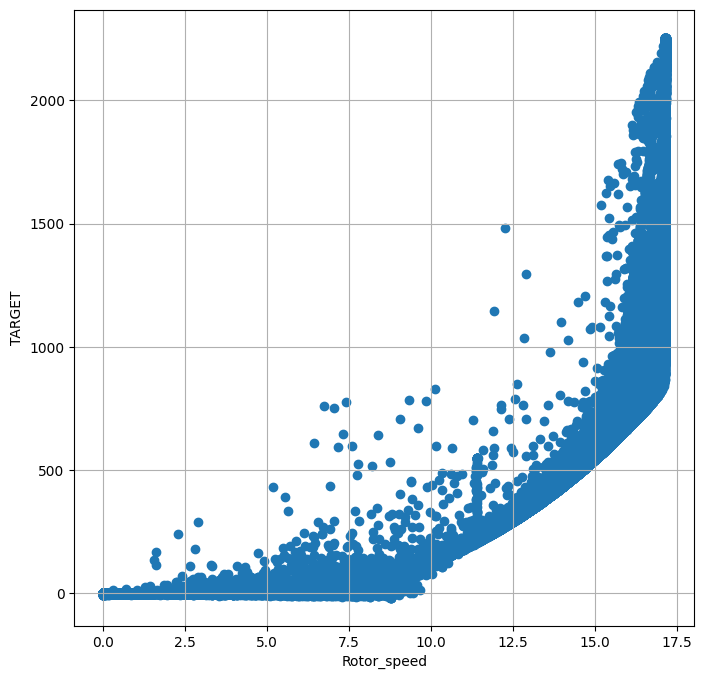

In [110]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(data['Rotor_speed'], data['TARGET'])
ax.grid()
ax.set_xlabel('Rotor_speed')
ax.set_ylabel('TARGET')
plt.show()

Commentaires :
- Les points éparses sont suspects.
- On a des puissances négatives (=suspectes)

Conseil pour afficher concentration des points : cf autre version du code.

On a donc des données qui contiennent des données hors de la norme attendue => il faut retirer les valeurs anormales compte tenu de l'objectif qui est de faire un modèle de conditions normales.

Idéalement il faudrait investiguer davantage sur ces données suspectes (interroger le métier)



On retire les puissances nulles ou négatives :

In [111]:
data = data[data['TARGET'] > 0]
print('Dimensions du jeu de données :', data.shape)

Dimensions du jeu de données : (135223, 80)


On échantillonne à 1/10 pour limiter les calculs dans ce notebook (on fixe la graine du générateur aléatoire pour éventuellement comparer les résultats):

In [112]:
sample_frac = 1/10
data = data.sample(frac=sample_frac, random_state=1789)
print('Dimensions du jeu de données :', data.shape)

Dimensions du jeu de données : (13522, 80)


### 1.4. Gestion des variables

In [113]:
features = list(data.columns.difference(['TARGET', 'MAC_CODE', 'Date_time']))

X = data[features]
y = data['TARGET']

### 1.5. Création d'un échantillon test

On fixe (ou pas) la graine du générateur aléatoire pour éventuellement comparer les résultats.

In [114]:
test_portion = 1/5

# X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=test_portion, random_state=1789)
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=test_portion)

print('Dimensions de X_train_valid :', X_train_valid.shape)
print('Dimensions de X_test        :', X_test.shape)
print('Dimensions de y_train_valid :', y_train_valid.shape)
print('Dimensions de y_test        :', y_test.shape)

Dimensions de X_train_valid : (10817, 77)
Dimensions de X_test        : (2705, 77)
Dimensions de y_train_valid : (10817,)
Dimensions de y_test        : (2705,)


### 1.6. Normalisation des covariables

Etape optionnelle à ce stade : car pas besoin de normaliser pour toutes les méhodes.
/!\ Attention toutefois à ne pas interpréter les coeffs des modèles linéaires si données centrées/réduites.

On produit le jeu de données normalisé (centrage-réduction) :

In [115]:
scaler = StandardScaler(with_mean=True, with_std=True)
scaler.fit(X_train_valid)

X_train_valid_norm = scaler.transform(X_train_valid)
X_test_norm        = scaler.transform(X_test)

---
## 2. Modélisation
---

**### /!\ ne pas faire de validation croisée (cf prgms de la session 1 car taille d'échantillon très grande => explosion tps de calcul pour 13000 données)**

Plan d'attaque:
- avant modélisation : (ajouter grahiques), faire un clustering ou ACP et voir si intérêt de faire un modèle par cluster
- modélisation sur 1/10 de l'échantillon: reg linéaire avec feature engineering, reg avec régularisation, forets, boosting, DNN
(pour tester et debugger)
- quand prgm prêt : modéliser sur ech total et calculer les hyperparamètres


Création du fichier de stockage des prévisions

**TO DO : ajouter boosting et DNN**

In [116]:
# df PREV : création du tableau de résultats - stocke les prévisions de chaque modèle
PREV = pd.DataFrame({"Y": data["TARGET"],
                     "MCO": 0.0, "BIC": 0.0, "AIC": 0.0,
                     "lasso": 0.0, "ridge": 0.0, "elastic": 0.0,
                     "ridgeGS": 0.0, "foret": 0.0,
                     }) # ajouter boosting et DNN

Création éch apprentissage et validation

In [117]:
valid_portion = 1/5

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=valid_portion, random_state=1234)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (8653, 77)
Dimensions de X_valid : (2164, 77)
Dimensions de X_test  : (2705, 77)
Dimensions de y_train : (8653,)
Dimensions de y_valid : (2164,)
Dimensions de y_test  : (2705,)


Configuration des modèles

In [118]:
# kf : KFold pour les méthodes pénalisées et arbres (10 blocs)
# kfaxes : KFold pour PCR et PLS (4 blocs, plus stable pour le choix du nb de composantes)

cr = StandardScaler()   # centre et réduit les variables (moyenne=0, écart-type=1) — indispensable pour les modèles pénalisés
kf = KFold(n_splits=10, shuffle=True, random_state=0)
kfaxes = KFold(n_splits=4, shuffle=True, random_state=0)
nbaxes = 20  # nb max de composantes à tester dans la grille (PCR et PLS)

lassocv = LassoCV(cv=kf)    # cherche automatiquement le meilleur lambda (force de pénalisation) par validation croisée
pipe_lassocv = Pipeline(steps=[("cr", cr), ("lassocv", lassocv)])   # applique d'abord la standardisation, puis le Lasso
etape_lassocv = pipe_lassocv.named_steps["lassocv"]    # on récupère le lamba optimal
lambdaoptlasso = []  # liste pour enregistrer le lambda optimal à chaque fold

enetcv = ElasticNetCV(cv=kf, max_iter=10000)
pipe_enetcv = Pipeline(steps=[("cr", cr), ("enetcv", enetcv)])

ridge = Ridge()
pipe_ridge = Pipeline(steps=[("cr", cr), ("ridge", ridge)])

# PCR : ACP + régression linéaire sur les composantes
acp = PCA()
reg_pcr = LinearRegression()
pipe_pcr = Pipeline(steps=[("cr", cr), ("acp", acp), ("reg", reg_pcr)])
param_grid_pcr = {"acp__n_components": list(range(1, nbaxes))}   # on teste sur 1 à 19 composantes → le meilleur nombre sera choisi par CV

# PLS : maximise la covariance entre X et Y dans l'espace réduit
regpls = PLSRegression()
param_grid_pls = {"n_components": list(range(1, nbaxes))}

Exécution des modèles sur éch d'apprentissage

In [119]:


Xapp  = X_train_valid
Xtest = X_test
Yapp = y_train_valid
Ytest = y_test

### MCO (toutes variables, sans sélection ni pénalité)
reg = LinearRegression()
reg.fit(Xapp, Yapp)

# PREV.loc[PREV.bloc == i, "MCO"] = reg.predict(Xtest) # This line will cause NameError for 'i' if no loop

### BIC (commenté : coûteux quand le nb de features est grand)
# inst_reg_bic = ols_step_sk.LinearRegressionSelectionFeatureIC(verbose=1, crit="bic")
# reg_bic = inst_reg_bic.fit(X=Xapp, y=Yapp)
# PREV.loc[PREV.bloc==i, "BIC"] = reg_bic.predict(Xtest)

### AIC
# inst_reg_aic = ols_step_sk.LinearRegressionSelectionFeatureIC(verbose=1, crit="aic")
# reg_aic = inst_reg_aic.fit(X=Xapp, y=Yapp)
# PREV.loc[PREV.bloc==i, "AIC"] = reg_aic.predict(Xtest)

### Lasso (sélection de variables via pénalité L1)
pipe_lassocv.fit(Xapp, Yapp)
# lambdaoptlasso.append(round(etape_lassocv.alpha_, 4))  # lambda optimal de ce fold
# PREV.loc[PREV.bloc == i, "lasso"] = pipe_lassocv.predict(Xtest)

### ElasticNet (compromis L1/L2)
pipe_enetcv.fit(Xapp, Yapp)
# PREV.loc[PREV.bloc == i, "elastic"] = pipe_enetcv.predict(Xtest)

### Ridge via RidgeCV (grille calée sur le chemin lasso × 100)
# etape_lassocv.alphas_ : grille de lambdas déjà explorée par le Lasso
# × 100 : le Ridge nécessite des lambdas beaucoup plus grands que le Lasso (échelles différentes)
# RidgeCV : méthode rapide intégrée à scikit-learn
alphasridge = 100 * etape_lassocv.alphas_
ridgecv = RidgeCV(cv=kf, alphas=alphasridge)
pipe_ridgecv = Pipeline(steps=[("cr", cr), ("ridgecv", ridgecv)])
pipe_ridgecv.fit(Xapp, Yapp)
# PREV.loc[PREV.bloc == i, "ridge"] = pipe_ridgecv.predict(Xtest)

### Ridge via GridSearchCV (alternative plus flexible)
# Même grille de lambdas, mais via GridSearchCV — plus flexible (on peut changer le scoring, paralléliser)
# n_jobs=3 : parallélisation sur 3 cœurs
# neg_mean_squared_error : on minimise le MSE (négatif car GridSearchCV maximise par convention)
param_grid_ridge = {"ridge__alpha": alphasridge}
cv_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=kf,
                        scoring="neg_mean_squared_error", n_jobs=3).fit(Xapp, Yapp)
# PREV.loc[PREV.bloc == i, "ridgeGS"] = cv_ridge.predict(Xtest)

### Arbre de décision (min 5 obs par feuille pour limiter le surapprentissage)
arbre = DecisionTreeRegressor(min_samples_leaf=5).fit(Xapp, Yapp)
# PREV.loc[PREV.bloc == i, "arbre"] = arbre.predict(Xtest)

### Forêt aléatoire
foret = RandomForestRegressor().fit(Xapp, Yapp)
# PREV.loc[PREV.bloc == i, "foret"] = foret.predict(Xtest)

### PCR : ACP puis régression linéaire sur les composantes
### nb de composantes choisi par GridSearchCV avec kfaxes (4 blocs)
cv_pcr = GridSearchCV(pipe_pcr, param_grid_pcr, cv=kfaxes,
                      scoring="neg_mean_squared_error", n_jobs=3).fit(Xapp, Yapp)
# PREV.loc[PREV.bloc == i, "pcr"] = cv_pcr.predict(Xtest)

### PLS : maximise la covariance entre X et Y dans l'espace réduit
### avantage sur PCR : tient compte de Y pour construire les composantes
cv_pls = GridSearchCV(regpls, param_grid_pls, cv=kfaxes,
                      scoring="neg_mean_squared_error", n_jobs=3).fit(Xapp, Yapp)
# PREV.loc[PREV.bloc == i, "pls"] = cv_pls.predict(Xtest)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 323779.9934449196, tolerance: 228708.65201638138
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 372096.3323523402, tolerance: 228708.65201638138
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 246184.242097497, tolerance: 228708.65201638138
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceW

Comparaison des prformances des modèles via MAE

** Changer méthode de calcul de MSE par MAE**

In [121]:
# MAE de chaque méthode
prev = PREV.iloc[:, 1:]     # iloc[:, 1:] sélectionne toutes les lignes, et toutes les colonnes à partir de la 2ème. On exclut la colonne bloc (colonne 0), qui n'est pas une prédiction
# moyenne des différences absolues entre Y et Y prev
np.round(abs(prev.sub(PREV.Y, axis=0)).mean(), 2)   # prev.sub(PREV.Y, axis=0) : soustrait Y de chaque colonne de prev

,0
MCO,404.89
BIC,404.89
AIC,404.89
lasso,404.89
ridge,404.89
elastic,404.89
ridgeGS,404.89
foret,404.89


/!\ problème dans code modélisation => tous les MAE sont les mêmes

In [123]:
print(f"PREV charge : {PREV.shape[0]} observations x {PREV.shape[1]} colonnes")
print(f"Methodes disponibles : {list(PREV.columns[2:])}")

PREV charge : 13522 observations x 9 colonnes
Methodes disponibles : ['BIC', 'AIC', 'lasso', 'ridge', 'elastic', 'ridgeGS', 'foret']


In [124]:
PREV.head()

,Y,MCO,BIC,AIC,lasso,ridge,elastic,ridgeGS,foret
382398,858.991000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
349608,667.084978,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
311806,0.078000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
416922,523.502011,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
327050,374.100000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
